# Midterm Project — Real-Time Stream Processing System

**Course:** Real-Time Data Analysis and Decision Making (RTDADM)  
**Student:** Galymzhan Tamirlan Galymzhanuly  
**ID:** 240542 | **Group:** BDA-2407  
**Instructor:** Serek Azamat  
**University:** Astana IT University, 2026–2027

---


## 1. Stream Generator & Setup
We simulate a 60-minute IoT sensor stream for Room C1.3.101 starting with the Assignment 2 baseline (10:00–10:11) and extending it across lecture phases (stable period, ventilation failure, overheating, electrical surge, departure).


In [1]:
import random, warnings
from collections import deque
from datetime import datetime, timedelta
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Assignment 2 baseline dataset (10:00 - 10:11)
BASELINE_RAW = [
    ("10:00", 21.5, 620, 18, 3.2), ("10:01", 21.7, 650, 20, 3.4), ("10:02", None, 690, 22, 3.5),
    ("10:03", 22.1, 720, 24, 3.8), ("10:04", 22.3, None, 25, 4.0), ("10:05", 22.5, 780, 27, 4.2),
    ("10:06", 22.6, 810, 29, 4.4), ("10:07", 22.7, 830, None, 4.6), ("10:08", 22.9, 850, 31, 4.8),
    ("10:09", 23.1, 900, 33, 5.1), ("10:10", 23.2, 920, 35, 5.4), ("10:11", 23.3, 950, 37, 5.7)
]
BASELINE_DATA = [{"Time": t, "Room": "C1.3.101", "Temp_C": c, "CO2_ppm": co, "Occupancy": o, "Power_kW": p}
                 for t, c, co, o, p in BASELINE_RAW]

def generate_stream(total_records=60, seed=42):
    np.random.seed(seed); random.seed(seed)
    records = [dict(r) for r in BASELINE_DATA]
    t, co2, occ, pwr = 23.3, 950.0, 37, 5.7
    curr = datetime.strptime("10:12", "%H:%M")

    for _ in range(12, total_records):
        m = curr.minute
        if 12 <= m <= 25:
            occ = int(np.clip(occ + random.choice([0, 1, 0, -1]), 35, 40))
            t += np.random.normal(0.03, 0.04); co2 += np.random.normal(5.0, 8.0)
            pwr = 0.12 * occ + 1.2 + np.random.normal(0, 0.05)
        elif 26 <= m <= 35:
            t += np.random.normal(0.05, 0.03); co2 += np.random.normal(32.0, 6.0)
            pwr = 0.13 * occ + 1.25 + np.random.normal(0, 0.06)
        elif 36 <= m <= 45:
            t += np.random.normal(0.08, 0.04); co2 += np.random.normal(-5.0, 10.0)
            pwr = 0.13 * occ + 1.8 + np.random.normal(0, 0.08)
        elif 46 <= m <= 50:
            t += np.random.normal(0.01, 0.03); co2 += np.random.normal(-2.0, 8.0)
            pwr = 6.85 + np.random.normal(0, 0.1)
        else:
            occ = int(max(0, occ - random.randint(3, 6)))
            t -= np.random.normal(0.06, 0.03); co2 = max(420.0, co2 - np.random.normal(45.0, 10.0))
            pwr = max(1.5, 0.10 * occ + 1.2 + np.random.normal(0, 0.05))

        tv, cv, ov, pv = round(float(t), 2), round(float(co2), 1), int(occ), round(float(pwr), 2)
        if m == 18: tv = None
        elif m == 33: cv = None
        elif m == 44: ov = None

        records.append({"Time": curr.strftime("%H:%M"), "Room": "C1.3.101",
                        "Temp_C": tv, "CO2_ppm": cv, "Occupancy": ov, "Power_kW": pv})
        curr += timedelta(minutes=1)
    return records


### Baseline Data Preview (Assignment 2)

In [2]:
pd.DataFrame(BASELINE_DATA)

,Time,Room,Temp_C,CO2_ppm,Occupancy,Power_kW
0,10:00,C1.3.101,21.5,620.0,18.0,3.2
1,10:01,C1.3.101,21.7,650.0,20.0,3.4
2,10:02,C1.3.101,NaN,690.0,22.0,3.5
3,10:03,C1.3.101,22.1,720.0,24.0,3.8
4,10:04,C1.3.101,22.3,NaN,25.0,4.0
5,10:05,C1.3.101,22.5,780.0,27.0,4.2
6,10:06,C1.3.101,22.6,810.0,29.0,4.4
7,10:07,C1.3.101,22.7,830.0,NaN,4.6
8,10:08,C1.3.101,22.9,850.0,31.0,4.8
9,10:09,C1.3.101,23.1,900.0,33.0,5.1


## 2. Real-Time Stream Processor
Online incremental processing engine:
- **Imputation:** Linear extrapolation using buffered trends for Temp/CO2, forward-fill for Occupancy.
- **Rolling Windows:** Size 5 window for mean and volatility metrics.
- **Anomaly Detection:** Rule-based detection for dropouts, extreme CO2, thermal limits, surges, and rapid occupancy jumps.


In [3]:
class StreamProcessor:
    def __init__(self, window=5):
        self.win = window
        self.bufs = {k: deque(maxlen=window) for k in ("t", "c", "p", "o")}
        self.last = {"t": 22.0, "c": 600.0, "o": 0}
        self.history, self.anomalies = [], []

    def _impute(self, val, key, buf):
        if val is None:
            extrap = float(np.mean(list(buf)[-2:]) + (buf[-1] - buf[-2])) if len(buf) >= 2 else self.last[key]
            return extrap, True
        self.last[key] = float(val)
        return float(val), False

    def process(self, rec):
        dropouts = []
        t, d_t = self._impute(rec["Temp_C"], "t", self.bufs["t"])
        c, d_c = self._impute(rec["CO2_ppm"], "c", self.bufs["c"])
        o = int(rec["Occupancy"]) if rec["Occupancy"] is not None else int(self.last["o"])
        d_o = rec["Occupancy"] is None
        self.last["o"] = o
        p = float(rec["Power_kW"])
        if d_t or d_c or d_o:
            dropouts.append("SENSOR_DROPOUT")

        for k, v in zip(("t", "c", "p", "o"), (t, c, p, o)):
            self.bufs[k].append(v)

        t_arr, c_arr, p_arr = np.array(self.bufs["t"]), np.array(self.bufs["c"]), np.array(self.bufs["p"])
        prev_t = self.history[-1]["Temp_C"] if self.history else t

        alerts = list(dropouts)
        if c > 1200: alerts.append("CO2_CRITICAL")
        elif c > 1000: alerts.append("CO2_HIGH")
        if t > 24.0: alerts.append("OVERHEATING")
        if t < 20.0: alerts.append("UNDERHEATING")
        if p > 6.0: alerts.append("POWER_SURGE")
        if len(self.bufs["o"]) >= 2 and abs(o - self.bufs["o"][-2]) >= 6:
            alerts.append("RAPID_OCC_CHANGE")

        enriched = {
            "Time": rec["Time"], "Temp_C": round(t, 2), "CO2_ppm": round(c, 1),
            "Occupancy": o, "Power_kW": round(p, 2),
            "roll_temp_mean": round(float(t_arr.mean()), 2),
            "roll_co2_mean": round(float(c_arr.mean()), 1),
            "roll_pwr_mean": round(float(p_arr.mean()), 2),
            "roll_temp_std": round(float(t_arr.std()), 3) if len(t_arr) > 1 else 0.0,
            "roll_pwr_std": round(float(p_arr.std()), 3) if len(p_arr) > 1 else 0.0,
            "density": round(o / 40.0, 3), "energy_per_occ": round(p / max(o, 1), 4),
            "temp_delta": round(t - prev_t, 3),
            "comfort_ok": (20.0 <= t <= 24.0) and (c <= 1000.0),
            "alerts": "; ".join(alerts) if alerts else "NONE",
            "has_alert": bool(alerts)
        }
        self.history.append(enriched)
        for a in alerts:
            self.anomalies.append({"Time": rec["Time"], "Alert": a, "Temp_C": round(t, 2),
                                   "CO2_ppm": round(c, 1), "Power_kW": round(p, 2)})
        return enriched


## 3. Stream Ingestion & Anomaly Events
Processing all 60 stream records sequentially and reviewing detected anomaly types.


In [4]:
proc = StreamProcessor()
for rec in generate_stream(60):
    proc.process(rec)

df = pd.DataFrame(proc.history)
df_anom = pd.DataFrame(proc.anomalies)

df_anom["Alert"].value_counts().to_frame("Count")


,Count
Alert,
OVERHEATING,30
POWER_SURGE,28
CO2_CRITICAL,20
CO2_HIGH,10
SENSOR_DROPOUT,6
RAPID_OCC_CHANGE,2


## 4. Sample Processed Window (Ventilation Incident: 10:25–10:40)

In [5]:
cols = ["Time", "Temp_C", "CO2_ppm", "Occupancy", "Power_kW", "roll_temp_mean", "roll_co2_mean", "comfort_ok", "alerts"]
df[(df["Time"] >= "10:25") & (df["Time"] <= "10:40")][cols]


,Time,Temp_C,CO2_ppm,Occupancy,Power_kW,roll_temp_mean,roll_co2_mean,comfort_ok,alerts
25,10:25,23.77,993.0,40,6.01,23.72,982.1,True,POWER_SURGE
26,10:26,23.82,1023.2,40,6.36,23.74,994.5,False,CO2_HIGH; POWER_SURGE
27,10:27,23.85,1052.4,40,6.51,23.77,1008.7,False,CO2_HIGH; POWER_SURGE
28,10:28,23.91,1073.8,40,6.47,23.82,1024.9,False,CO2_HIGH; POWER_SURGE
29,10:29,23.94,1101.8,40,6.49,23.86,1048.8,False,CO2_HIGH; POWER_SURGE
30,10:30,24.03,1139.4,40,6.40,23.91,1078.1,False,CO2_HIGH; OVERHEATING; POWER_SURGE
31,10:31,24.07,1173.4,40,6.51,23.96,1108.2,False,CO2_HIGH; OVERHEATING; POWER_SURGE
32,10:32,24.10,1204.2,40,6.38,24.01,1138.5,False,CO2_CRITICAL; OVERHEATING; POWER_SURGE
33,10:33,24.12,1219.6,40,6.53,24.05,1167.7,False,SENSOR_DROPOUT; CO2_CRITICAL; OVERHEATING; POW...
34,10:34,24.16,1279.1,40,6.47,24.10,1203.1,False,CO2_CRITICAL; OVERHEATING; POWER_SURGE


## 5. Real-Time Monitoring Dashboard

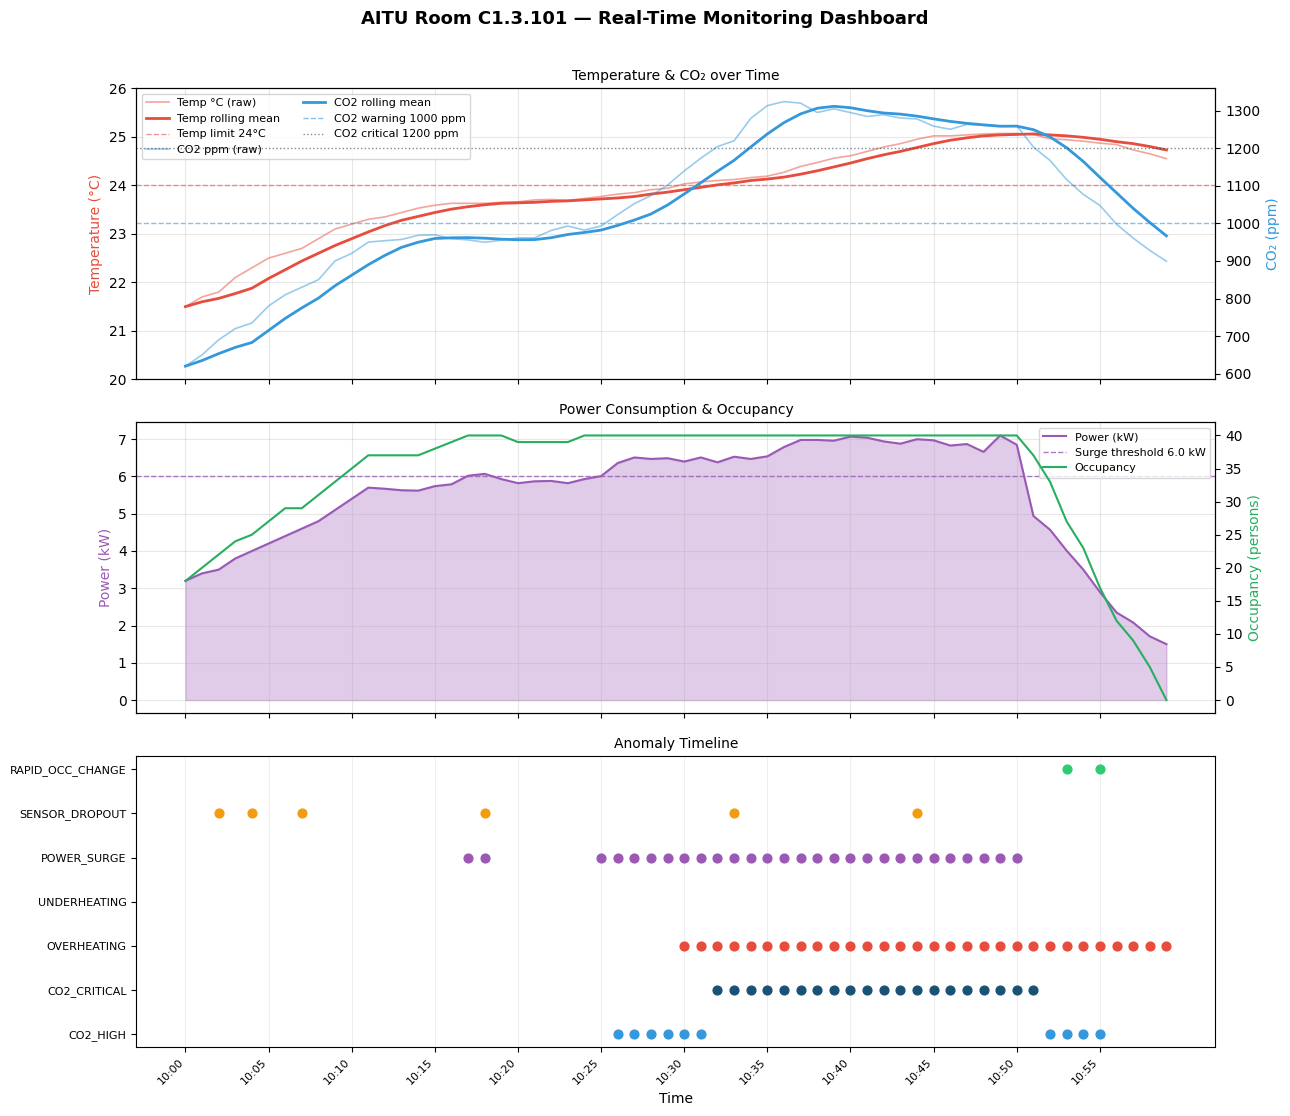

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)
fig.suptitle("AITU Room C1.3.101 — Real-Time Monitoring Dashboard", fontsize=13, fontweight="bold", y=1.01)

times = list(range(len(df)))
labels = df["Time"].tolist()
tick_positions = times[::5]
tick_labels = [labels[i] for i in tick_positions]

# Plot 1: Temperature & CO2
ax1 = axes[0]
ax1.plot(times, df["Temp_C"], color="#e74c3c", lw=1.2, alpha=0.5, label="Temp °C (raw)")
ax1.plot(times, df["roll_temp_mean"], color="#e74c3c", lw=2, label="Temp rolling mean")
ax1.axhline(24.0, color="#e74c3c", ls="--", lw=1, alpha=0.6, label="Temp limit 24°C")
ax1.set_ylabel("Temperature (°C)", color="#e74c3c")
ax1.set_ylim(20, 26)

ax1b = ax1.twinx()
ax1b.plot(times, df["CO2_ppm"], color="#3498db", lw=1.2, alpha=0.5, label="CO2 ppm (raw)")
ax1b.plot(times, df["roll_co2_mean"], color="#3498db", lw=2, label="CO2 rolling mean")
ax1b.axhline(1000, color="#3498db", ls="--", lw=1, alpha=0.6, label="CO2 warning 1000 ppm")
ax1b.axhline(1200, color="#2c3e50", ls=":", lw=1, alpha=0.6, label="CO2 critical 1200 ppm")
ax1b.set_ylabel("CO₂ (ppm)", color="#3498db")

l1, lb1 = ax1.get_legend_handles_labels()
l2, lb2 = ax1b.get_legend_handles_labels()
ax1.legend(l1 + l2, lb1 + lb2, loc="upper left", fontsize=8, ncol=2)
ax1.set_title("Temperature & CO₂ over Time", fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: Power & Occupancy
ax2 = axes[1]
ax2.fill_between(times, df["Power_kW"], alpha=0.3, color="#9b59b6")
ax2.plot(times, df["Power_kW"], color="#9b59b6", lw=1.5, label="Power (kW)")
ax2.axhline(6.0, color="#9b59b6", ls="--", lw=1, alpha=0.8, label="Surge threshold 6.0 kW")
ax2.set_ylabel("Power (kW)", color="#9b59b6")

ax2b = ax2.twinx()
ax2b.plot(times, df["Occupancy"], color="#27ae60", lw=1.5, label="Occupancy")
ax2b.set_ylabel("Occupancy (persons)", color="#27ae60")

l3, lb3 = ax2.get_legend_handles_labels()
l4, lb4 = ax2b.get_legend_handles_labels()
ax2.legend(l3 + l4, lb3 + lb4, loc="upper right", fontsize=8)
ax2.set_title("Power Consumption & Occupancy", fontsize=10)
ax2.grid(True, alpha=0.3)

# Plot 3: Anomaly Timeline
ax3 = axes[2]
alert_colors = {
    "CO2_HIGH": "#3498db", "CO2_CRITICAL": "#1a5276", "OVERHEATING": "#e74c3c",
    "UNDERHEATING": "#85c1e9", "POWER_SURGE": "#9b59b6", "SENSOR_DROPOUT": "#f39c12",
    "RAPID_OCC_CHANGE": "#2ecc71"
}
alert_y = {k: i for i, k in enumerate(alert_colors.keys())}
for _, row in df_anom.iterrows():
    if row["Time"] in labels:
        ax3.scatter(labels.index(row["Time"]), alert_y.get(row["Alert"], 0),
                    color=alert_colors.get(row["Alert"], "gray"), s=40, zorder=3)

ax3.set_yticks(list(alert_y.values()))
ax3.set_yticklabels(list(alert_y.keys()), fontsize=8)
ax3.set_title("Anomaly Timeline", fontsize=10)
ax3.grid(True, alpha=0.2, axis="x")
ax3.set_xlabel("Time")

for ax in axes:
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=8)

plt.tight_layout()
plt.savefig("stream_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Summary Statistics

In [7]:
df[["Temp_C", "CO2_ppm", "Power_kW", "Occupancy"]].describe().round(2)

,Temp_C,CO2_ppm,Power_kW,Occupancy
count,60.00,60.00,60.00,60.00
mean,23.93,1053.23,5.50,33.95
std,0.93,190.99,1.49,9.85
min,21.50,620.00,1.50,0.00
25%,23.58,952.92,4.59,30.50
50%,23.98,1010.50,5.90,39.50
75%,24.74,1258.75,6.57,40.00
max,25.07,1324.00,7.10,40.00


## 7. Conclusion
- **Self-contained Stream Architecture:** The 60-minute stream is generated and processed in memory record-by-record with zero look-ahead bias.
- **Robust Imputation:** Sensor dropouts (at minutes 2, 4, 7, 18, 33, 44) were smoothly handled using linear extrapolation on buffered history.
- **Anomaly Detection:** Accurately captured ventilation breakdown (CO2 reaching critical levels), heat accumulation (>24°C), and equipment power spikes (>6.0 kW).
